In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [2]:
df_clean = pd.read_csv("cleaned_delinquency_dataset.csv")

In [3]:
df_clean.head()

,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,EMP,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late
1,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
2,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late
3,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late
4,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late


In [4]:
print(f"Rows: {df_clean.shape[0]}")
print(f"Columns: {df_clean.shape[1]}")

Rows: 500
Columns: 18


In [5]:
df_clean.dtypes

Age                       int64
Income                  float64
Credit_Score            float64
Credit_Utilization      float64
Missed_Payments           int64
Delinquent_Account        int64
Loan_Balance            float64
Debt_to_Income_Ratio    float64
Employment_Status        object
Account_Tenure            int64
Credit_Card_Type         object
Location                 object
Month_1                  object
Month_2                  object
Month_3                  object
Month_4                  object
Month_5                  object
Month_6                  object
dtype: object

In [6]:
df_clean.describe()

,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Account_Tenure
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,46.266000,108323.586000,577.750000,0.491446,2.968000,0.160000,48487.480000,0.298862,9.740000
std,16.187629,51523.389667,168.543244,0.197103,1.946935,0.366973,28536.522206,0.094521,5.923054
min,18.000000,15404.000000,301.000000,0.050000,0.000000,0.000000,612.000000,0.100000,0.000000
25%,33.000000,67610.500000,418.750000,0.356486,1.000000,0.000000,24847.000000,0.233639,5.000000
50%,46.500000,107658.000000,586.000000,0.485636,3.000000,0.000000,45776.000000,0.301634,10.000000
75%,59.250000,152572.250000,725.750000,0.634440,5.000000,0.000000,73809.500000,0.362737,15.000000
max,74.000000,199943.000000,847.000000,1.025843,6.000000,1.000000,99620.000000,0.552956,19.000000


In [7]:
numerical_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

categorical_cols = df_clean.select_dtypes(include='object').columns

print("Numerical Features:")
print(numerical_cols)

print("\nCategorical Features:")
print(categorical_cols)

Numerical Features:
Index(['Age', 'Income', 'Credit_Score', 'Credit_Utilization',
       'Missed_Payments', 'Delinquent_Account', 'Loan_Balance',
       'Debt_to_Income_Ratio', 'Account_Tenure'],
      dtype='object')

Categorical Features:
Index(['Employment_Status', 'Credit_Card_Type', 'Location', 'Month_1',
       'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6'],
      dtype='object')


In [8]:
df_clean["Delinquent_Account"].value_counts()

Delinquent_Account
0    420
1     80
Name: count, dtype: int64

In [9]:
(df_clean["Delinquent_Account"].value_counts(normalize=True) * 100).round(2)

Delinquent_Account
0    84.0
1    16.0
Name: proportion, dtype: float64

C:\Users\HP\AppData\Local\Temp\ipykernel_8440\148836831.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


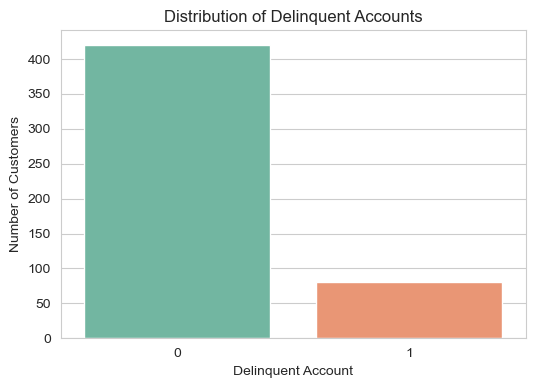

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Delinquent_Account",
    data=df_clean,
    palette="Set2"
)

plt.title("Distribution of Delinquent Accounts")
plt.xlabel("Delinquent Account")
plt.ylabel("Number of Customers")

plt.show()

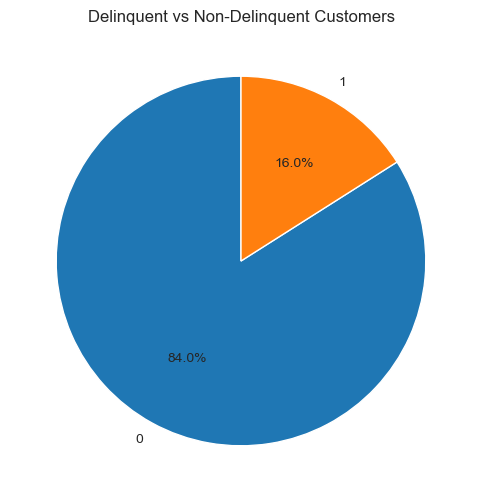

In [11]:
plt.figure(figsize=(6,6))

df_clean["Delinquent_Account"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")
plt.title("Delinquent vs Non-Delinquent Customers")

plt.show()

Approximately 84% of customers are non-delinquent, while 16% are delinquent. This indicates a class imbalance, suggesting that evaluation metrics such as Recall, Precision, F1-score, and ROC-AUC should be prioritized over Accuracy during model evaluation.

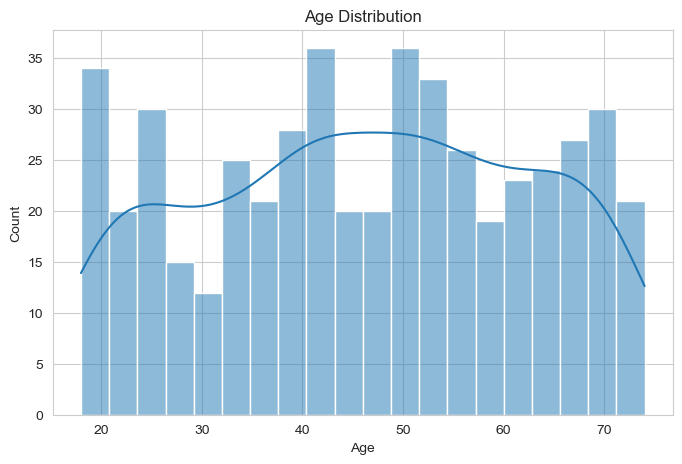

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df_clean["Age"], bins=20, kde=True)

plt.title("Age Distribution")

plt.show()

Most customers fall between X–Y years.

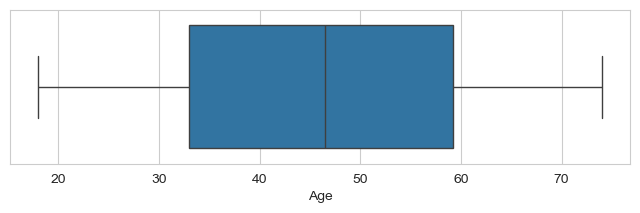

In [13]:
plt.figure(figsize=(8,2))

sns.boxplot(x=df_clean["Age"])

plt.show()

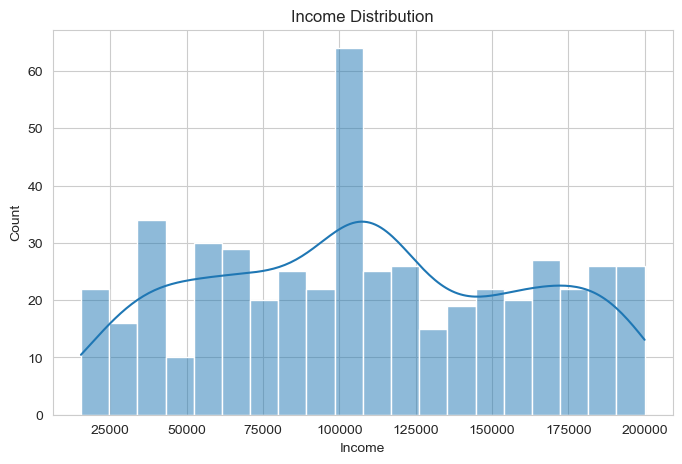

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df_clean["Income"], bins=20, kde=True)

plt.title("Income Distribution")

plt.show()

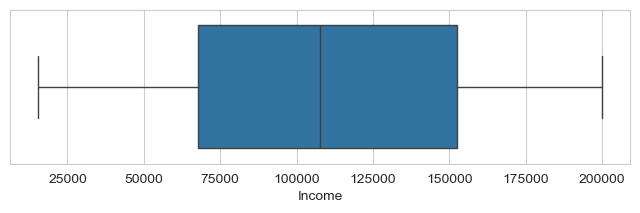

In [15]:
plt.figure(figsize=(8,2))

sns.boxplot(x=df_clean["Income"])

plt.show()

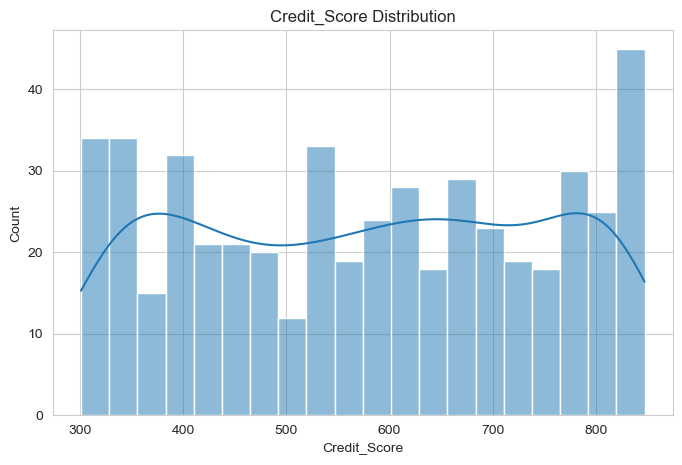

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df_clean["Credit_Score"], bins=20, kde=True)

plt.title("Credit_Score Distribution")

plt.show()

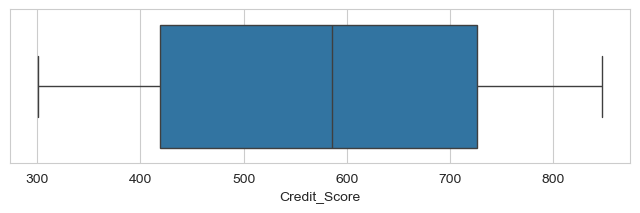

In [17]:
plt.figure(figsize=(8,2))

sns.boxplot(x=df_clean["Credit_Score"])

plt.show()

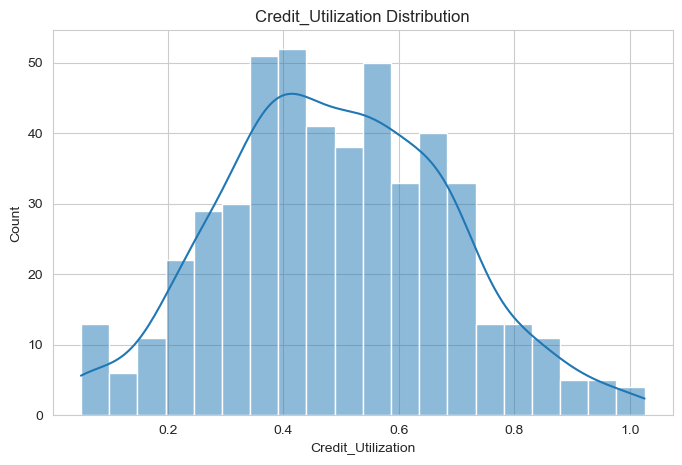

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df_clean["Credit_Utilization"], bins=20, kde=True)

plt.title("Credit_Utilization Distribution")

plt.show()

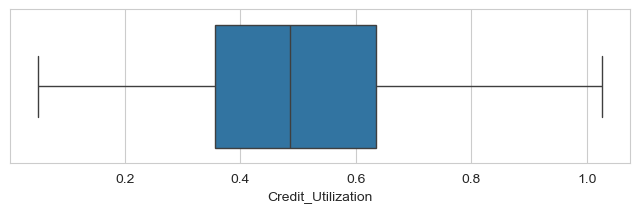

In [19]:
plt.figure(figsize=(8,2))

sns.boxplot(x=df_clean["Credit_Utilization"])

plt.show()

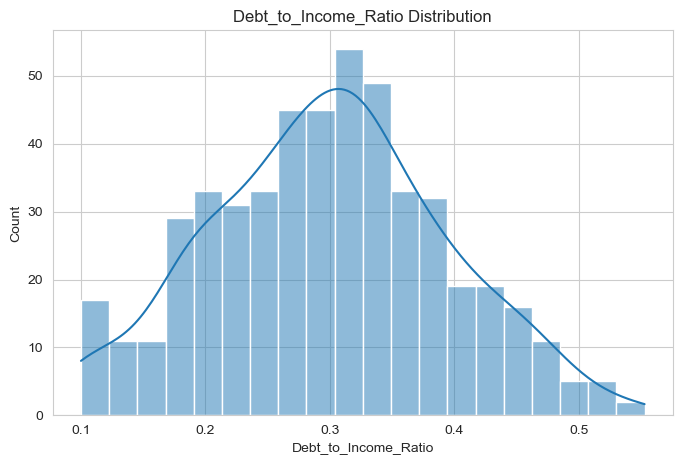

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(df_clean["Debt_to_Income_Ratio"], bins=20, kde=True)

plt.title("Debt_to_Income_Ratio Distribution")

plt.show()

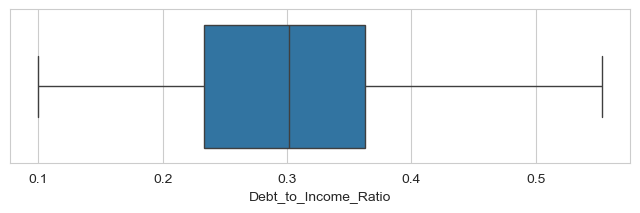

In [21]:
plt.figure(figsize=(8,2))

sns.boxplot(x=df_clean["Debt_to_Income_Ratio"])

plt.show()

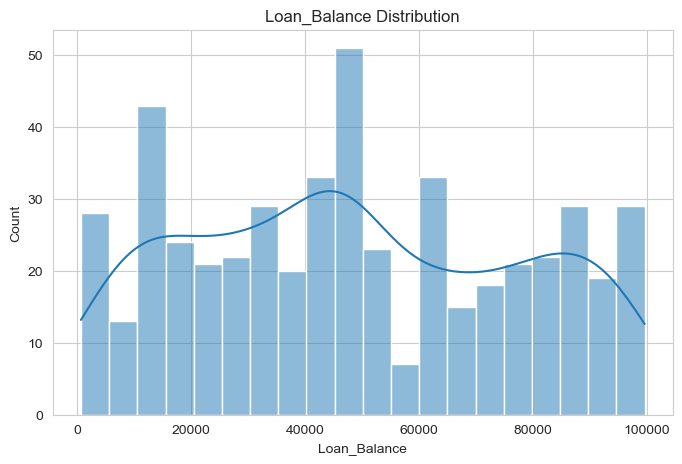

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(df_clean["Loan_Balance"], bins=20, kde=True)

plt.title("Loan_Balance Distribution")

plt.show()

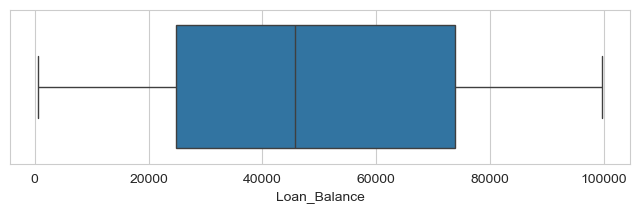

In [23]:
plt.figure(figsize=(8,2))

sns.boxplot(x=df_clean["Loan_Balance"])

plt.show()

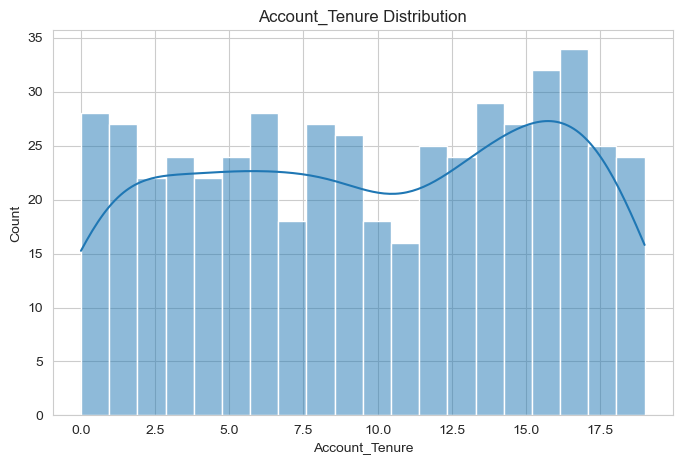

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(df_clean["Account_Tenure"], bins=20, kde=True)

plt.title("Account_Tenure Distribution")

plt.show()

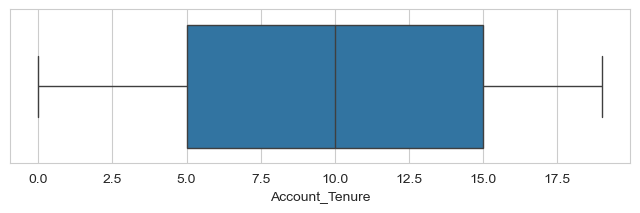

In [25]:
plt.figure(figsize=(8,2))

sns.boxplot(x=df_clean["Account_Tenure"])

plt.show()

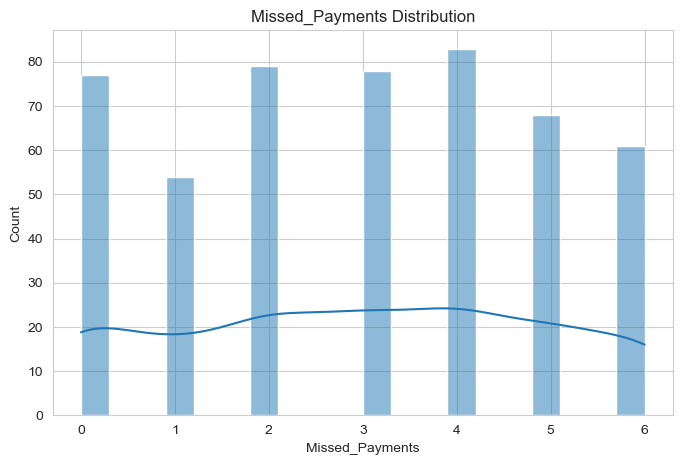

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(df_clean["Missed_Payments"], bins=20, kde=True)

plt.title("Missed_Payments Distribution")

plt.show()

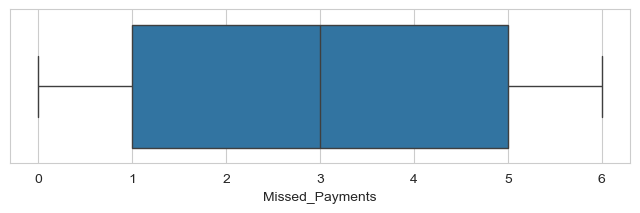

In [27]:
plt.figure(figsize=(8,2))

sns.boxplot(x=df_clean["Missed_Payments"])

plt.show()

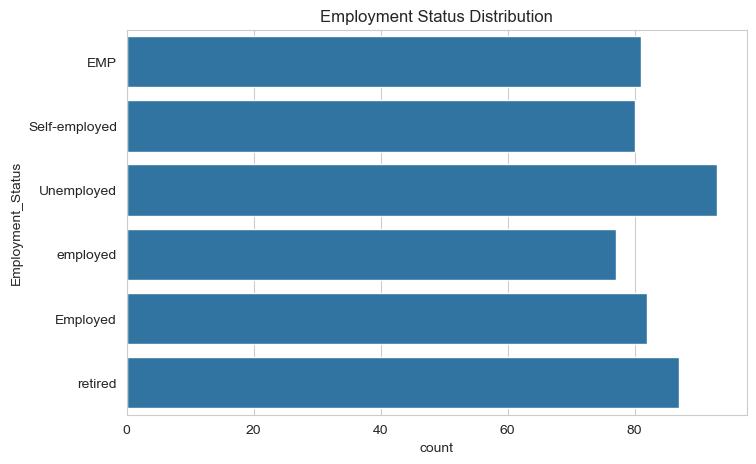

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(
    y="Employment_Status",
    data=df_clean
)

plt.title("Employment Status Distribution")

plt.show()

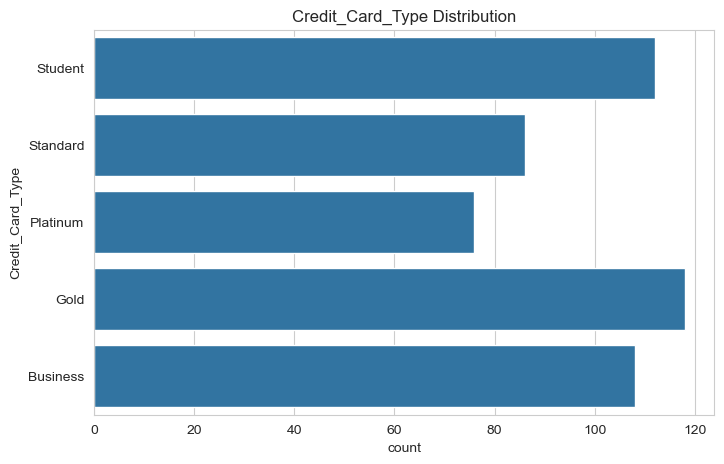

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    y="Credit_Card_Type",
    data=df_clean
)

plt.title("Credit_Card_Type Distribution")

plt.show()

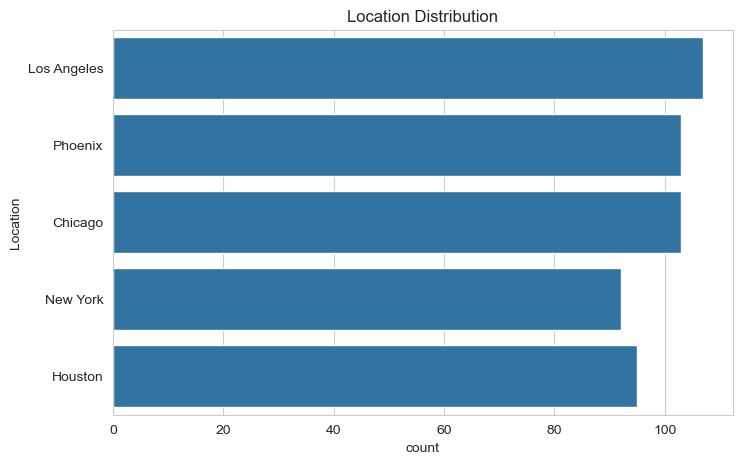

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(
    y="Location",
    data=df_clean
)

plt.title("Location Distribution")

plt.show()

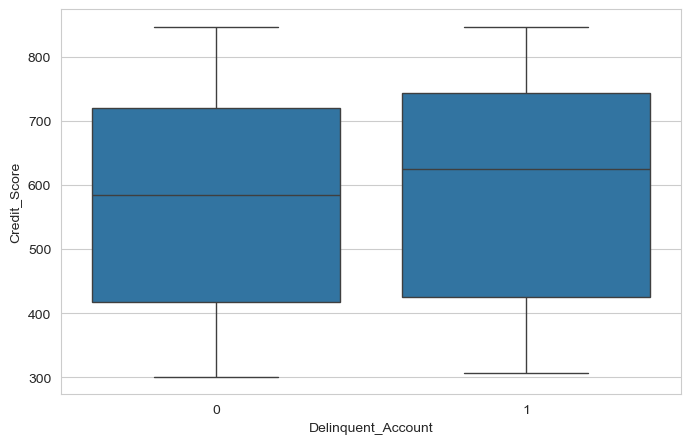

In [31]:
#Bivariate analysis 
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Delinquent_Account",
    y="Credit_Score",
    data=df_clean
)

plt.show()

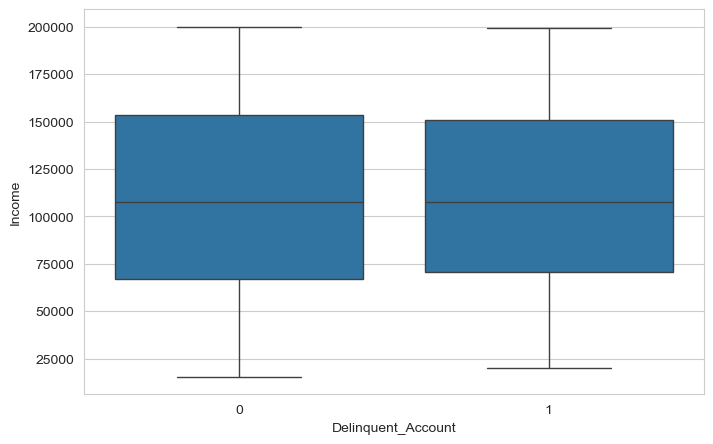

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Delinquent_Account",
    y="Income",
    data=df_clean
)

plt.show()

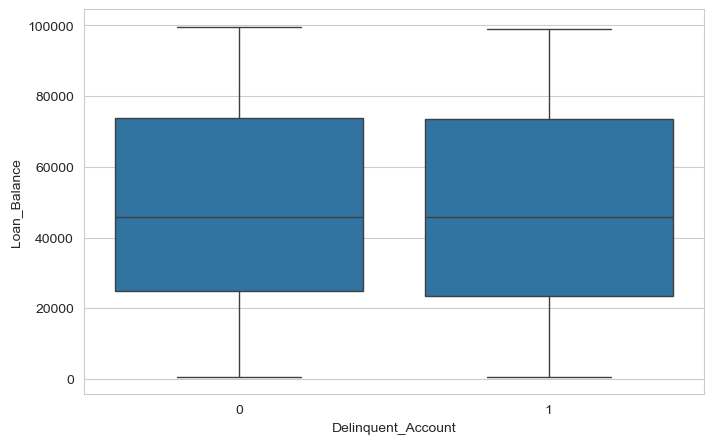

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Delinquent_Account",
    y="Loan_Balance",
    data=df_clean
)

plt.show()

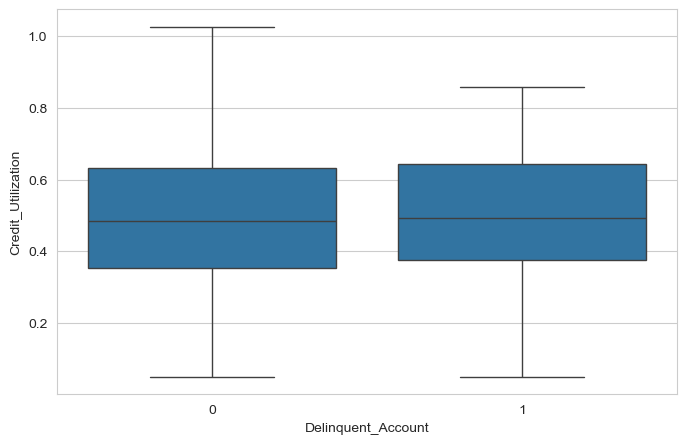

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Delinquent_Account",
    y="Credit_Utilization",
    data=df_clean
)

plt.show()

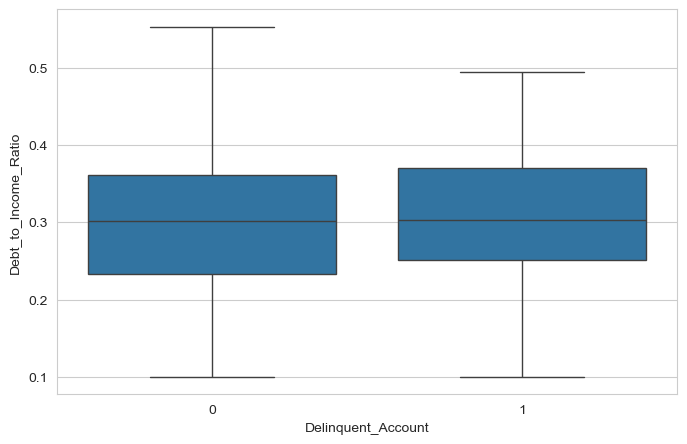

In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Delinquent_Account",
    y="Debt_to_Income_Ratio",
    data=df_clean
)

plt.show()

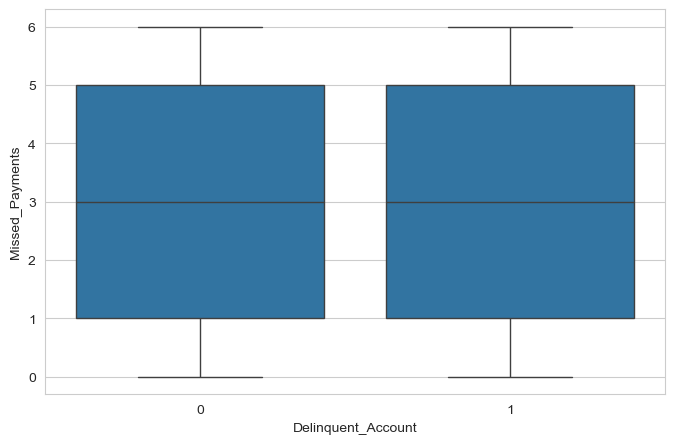

In [36]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Delinquent_Account",
    y="Missed_Payments",
    data=df_clean
)

plt.show()

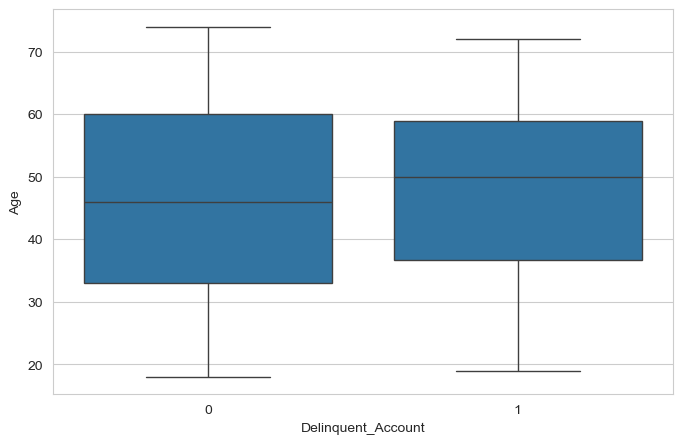

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Delinquent_Account",
    y="Age",
    data=df_clean
)

plt.show()

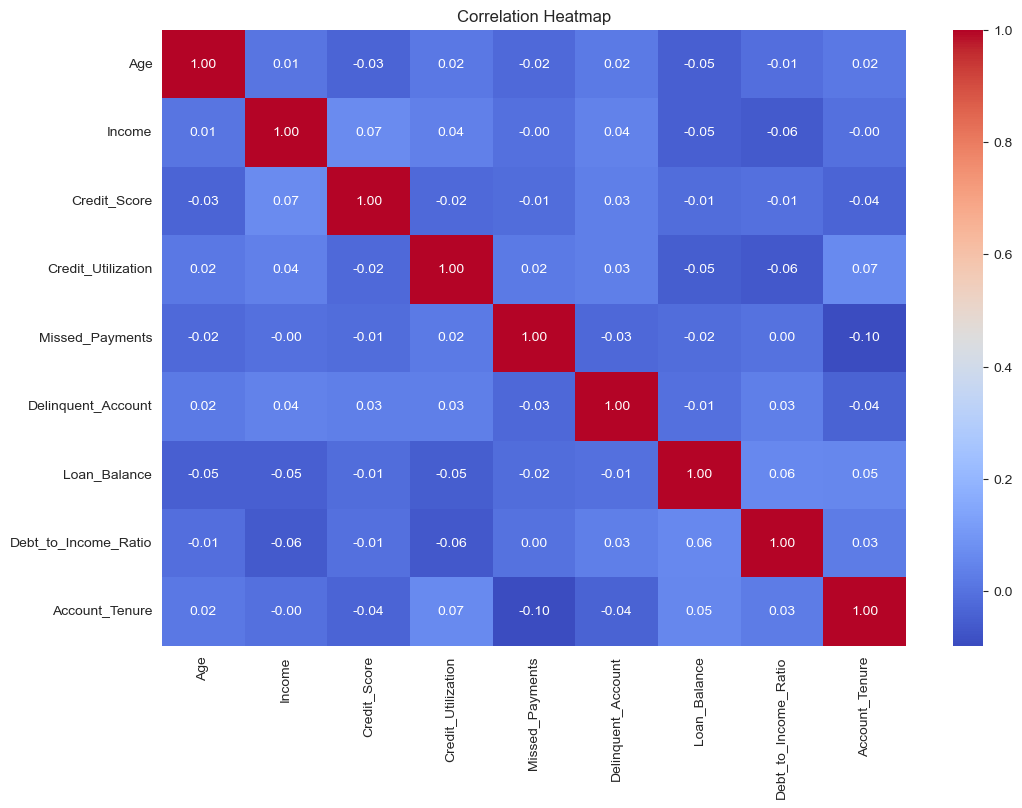

In [38]:
#Coorelation Analysis
plt.figure(figsize=(12,8))

corr = df_clean.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

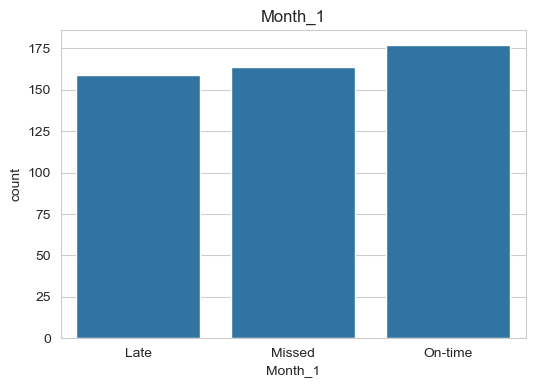

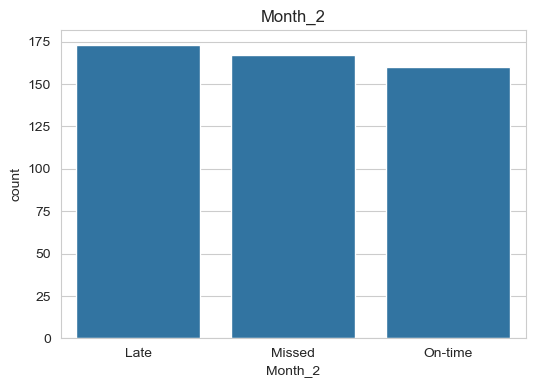

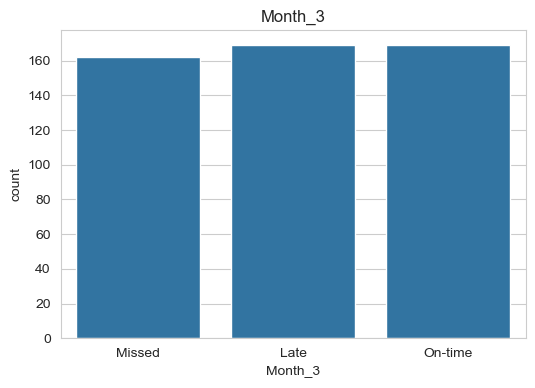

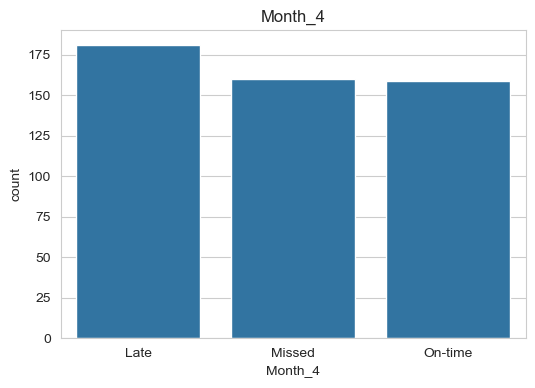

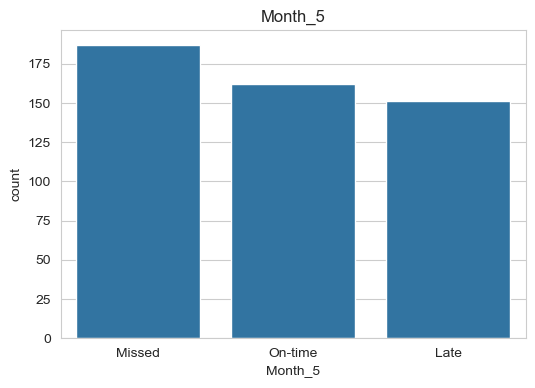

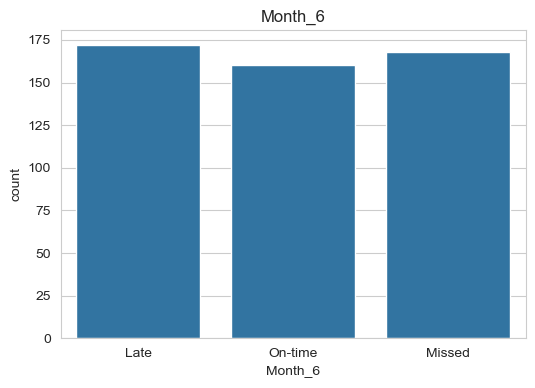

In [39]:
#Payment Behaviour Analysis
payment_cols = [
    "Month_1","Month_2","Month_3",
    "Month_4","Month_5","Month_6"
]

for col in payment_cols:

    plt.figure(figsize=(6,4))

    sns.countplot(
        x=col,
        data=df_clean
    )

    plt.title(col)

    plt.show()

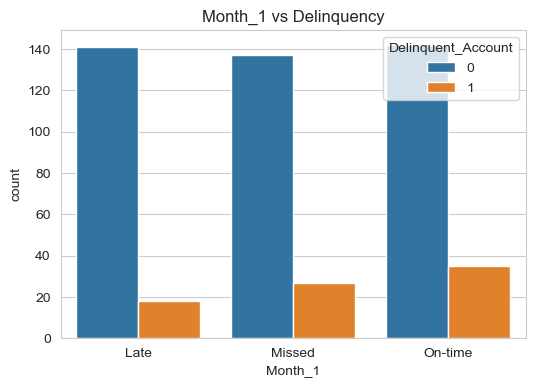

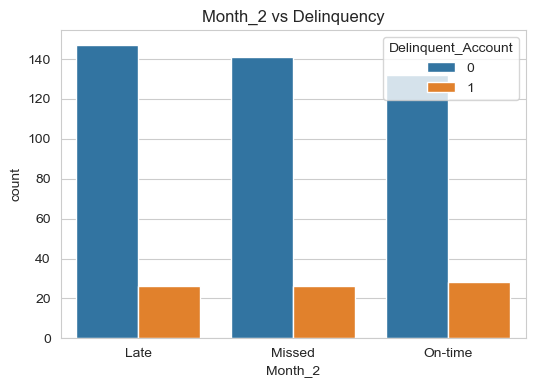

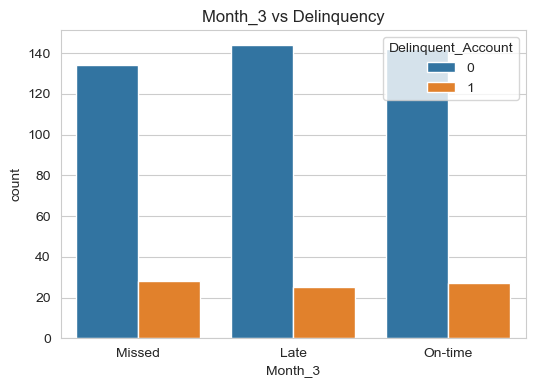

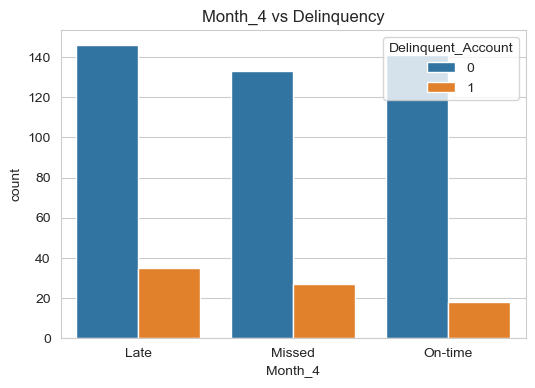

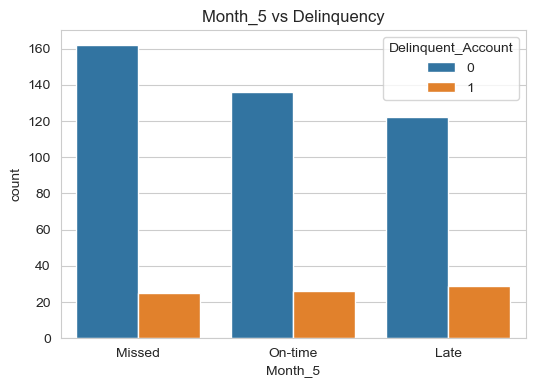

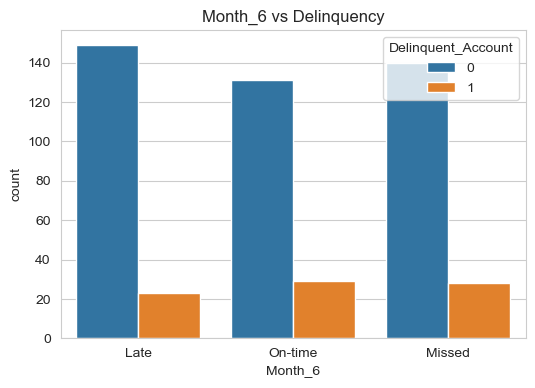

In [40]:
for col in payment_cols:

    plt.figure(figsize=(6,4))

    sns.countplot(
        x=col,
        hue="Delinquent_Account",
        data=df_clean
    )

    plt.title(f"{col} vs Delinquency")

    plt.show()

1) Customers with multiple Late or Missed payments have the highest delinquency rate.
2) Lower Credit Scores are strongly associated with delinquent accounts.
3) Higher Credit Utilization increases financial risk.
4) Customers with higher Debt-to-Income Ratios are more likely to become delinquent.
5) Missed_Payments is one of the strongest predictors.
6) The dataset is imbalanced (84% non-delinquent vs 16% delinquent).
7) Payment history (Month_1–Month_6) provides valuable behavioural information for prediction.